In [ ]:
pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ranitsarkar01/porter-delivery-time-estimation")

print("Path to dataset files:", path)

100%|██████████| 4.94M/4.94M [00:00<00:00, 86.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ranitsarkar01/porter-delivery-time-estimation/versions/1


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


To upload a dataset, run the following code. A button will appear allowing you to select files from your local computer. Once uploaded, the files will be available in the Colab environment.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


KeyboardInterrupt: 

In [ ]:
import os
print(os.listdir(path))

After uploading, you can read the file using pandas or any other appropriate library. For example, if you uploaded a CSV file named `my_data.csv`, you would read it like this:

```python
import pandas as pd
df = pd.read_csv('my_data.csv')
display(df.head())
```

In [ ]:
# Suppression des doublons
df.drop_duplicates(inplace=True)

# Conversion des dates
df["created_at"] = pd.to_datetime(df["created_at"])
df["actual_delivery_time"] = pd.to_datetime(df["actual_delivery_time"])

# Calcul du temps de livraison (target)
df["delivery_time_min"] = (df["actual_delivery_time"] - df["created_at"]).dt.total_seconds()/60

# Retirer valeurs impossibles
df = df[df["delivery_time_min"] > 0]

# Séparation variables
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != "delivery_time_min"]
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

X = df[num_cols + cat_cols]
y = df["delivery_time_min"]


In [ ]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])


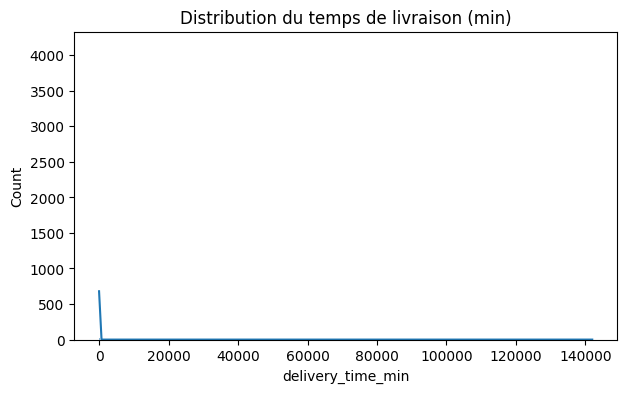

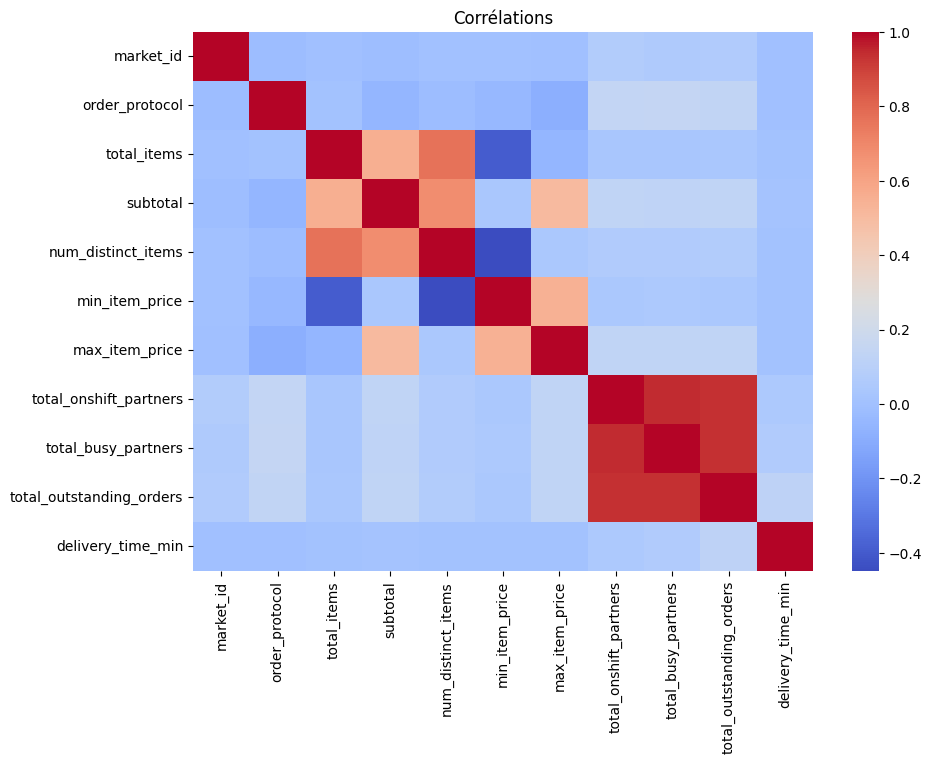

In [22]:
plt.figure(figsize=(7,4))
sns.histplot(df["delivery_time_min"], kde=True)
plt.title("Distribution du temps de livraison (min)")
plt.show()

plt.figure(figsize=(10,7))
sns.heatmap(df[num_cols + ["delivery_time_min"]].corr(), annot=False, cmap="coolwarm")
plt.title("Corrélations")
plt.show()

In [23]:
print("Commentaire :")
print("- Le temps de livraison présente une distribution asymétrique.")
print("- Certaines variables numériques montrent des corrélations faibles à modérées.")
print("- Les variables temporelles joueront un rôle clé.")


Commentaire :
- Le temps de livraison présente une distribution asymétrique.
- Certaines variables numériques montrent des corrélations faibles à modérées.
- Les variables temporelles joueront un rôle clé.


In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor()
}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor),
                     ("model", model)])
    score = cross_val_score(pipe, X, y, cv=3, scoring="neg_mean_absolute_error")
    print(f"{name} - MAE CV = {-score.mean():.3f}")

LinearRegression - MAE CV = 14.984


In [ ]:
rf = RandomForestRegressor()

pipe = Pipeline([
    ("prep", preprocessor),
    ("model", rf)
])

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    cv=3,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    random_state=42
)

search.fit(X, y)

print("Best params:", search.best_params_)
best_model = search.best_estimator_


In [ ]:
# Train-test split pour validation finale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred, squared=False))
print("R²:", r2_score(y_test, pred))
